Embiddig is nothing but converting the texts into numbers or you can say vectors which computers understand son that we can do similarity search on them from vectorDBs and can find the related infos

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#example vector embedding
word_embeddings = {
    "cat" : [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}



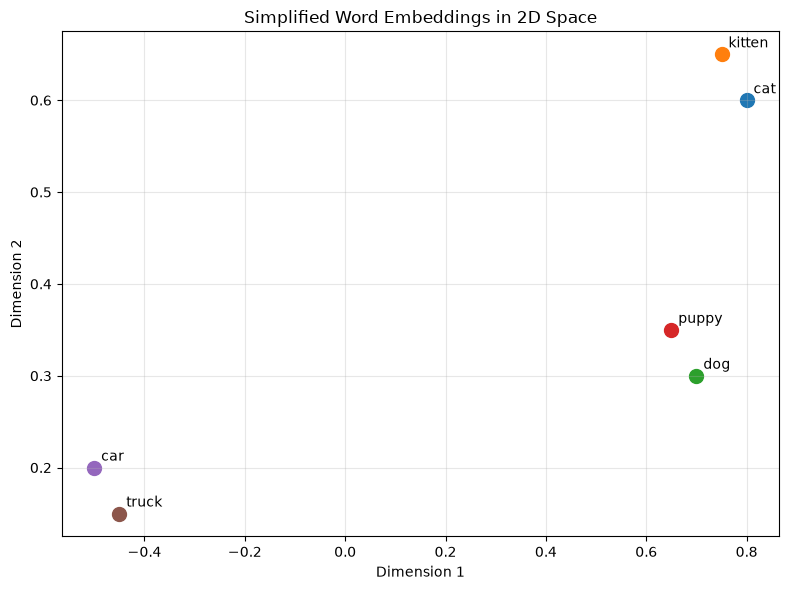

In [5]:
fig, ax = plt.subplots(figsize=(8,6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word,(coords[0], coords[1]),xytext=(5, 5),textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
## NOW HOW THE SIMILARITY SEARCH IS BEING PERFORMED 
# FOR THAT WE USE COSINE SIMILARITY RULE OF TWO VECTORS
# COSINE SIMILAR = DOT_PRODUCT(V1,V2)/(MAG_V1 * MAG_V2)

def cosine_similarity(vec1,vec2):
    """
    1. result if close to 1: very similar
    2. result is close to 0: less similar
    3. result is close to -1: opposite meaning
    """
    dot_prod = np.dot(vec1,vec2)
    mag_v1 = np.linalg.norm(vec1)
    mag_v2 = np.linalg.norm(vec2)
    return dot_prod/(mag_v1 * mag_v2)



In [ ]:
cat_kitten_similar = cosine_similarity(word_embeddings["cat"],word_embeddings["kitten"])
print(cat_kitten_similar) #--> almost close to 1

cat_car_similar = cosine_similarity(word_embeddings["cat"],word_embeddings["car"])
print(cat_car_similar) #--> almost close to -1



0.9975095892825593
-0.5199469468957452


### Creating first embeddings

#### Hugging face Embeding

In [ ]:
## Method1: Creating using hugging face rmbedding models
from langchain_huggingface import HuggingFaceEmbeddings
#creating a embedding object of "all-MiniLM-L6-v2" sentence tranformer model from hugging face which does not ned any api key
embedding = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)
embedding


text = "Hello how are you!"
vec_embedd = embedding.embed_query(text) # emned_query used when only one sentence is present
print(vec_embedd)


texts = [
    "hello how are you",
    "my name is subhadeep",
    "what is your name?"
]
vec_embedd2 = embedding.embed_documents(texts) # emned_query used when only one sentence is present
print(vec_embedd2) ##--> will return list of vectors(for each of sentence)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6634.62it/s]


[-0.022092197090387344, 0.04474697262048721, 0.0835401639342308, 0.03952210396528244, -0.032685525715351105, -0.055102065205574036, 0.03350848704576492, -0.017814135178923607, -0.10817457735538483, 0.0460362583398819, -0.02819741889834404, 0.015582246705889702, -0.011987567879259586, -0.04084279388189316, 0.043222252279520035, -0.02491149865090847, 0.07686548680067062, -0.059934813529253006, -0.0861685648560524, 0.0486929751932621, -0.011186839081346989, 0.01595676876604557, -0.0009027024498209357, 0.08120984584093094, -0.06250172853469849, -0.032938554883003235, 3.892742097377777e-05, 0.005164918955415487, 0.041051484644412994, -0.10636291652917862, -0.03192459046840668, 0.07343744486570358, -0.022401602938771248, 0.010983960703015327, -0.009000828489661217, 0.02939385361969471, -0.012143174186348915, -0.12182268500328064, 0.005234923679381609, -0.006675930228084326, 0.0036889170296490192, -0.03696556016802788, -0.004141923505812883, -0.03284323960542679, 0.06511715054512024, -0.05371

In [13]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },

    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },

    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },

    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },

    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📖 Popular Open Source Embedding Models:\n")

for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"   📏 Embedding size: {info['size']} dimensions")
    print(f"   📄 Description: {info['description']}")
    print(f"   🎯 Use case: {info['use_case']}\n")

📖 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
   📏 Embedding size: 384 dimensions
   📄 Description: Fast and efficient, good quality
   🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
   📏 Embedding size: 768 dimensions
   📄 Description: Best quality, slower than MiniLM
   🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
   📏 Embedding size: 384 dimensions
   📄 Description: Slightly better than L6, bit slower
   🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
   📏 Embedding size: 384 dimensions
   📄 Description: Optimized for question-answering
   🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
   📏 Embedding size: 384 dimensions
   📄 Description: Supports 50+ languages
   🎯 Use case: Multilingual applications



#### OpenAI Embedding models

In [ ]:
# the codes are same just you need the api key, langchain_openai 's --> OpenAiEmbeddings,
# load the api key .env file anf then load it using dotenv libraruy

### Doing cosine similarity using OpenAI Embiding model


In [ ]:
from langchain_openai import OpenAIEmbeddings
embedding = OpenAIEmbeddings( model_name = "...")

def cosine_similarity(vec1,vec2):
    """
    1. result if close to 1: very similar
    2. result is close to 0: less similar
    3. result is close to -1: opposite meaning
    """
    dot_prod = np.dot(vec1,vec2)
    mag_v1 = np.linalg.norm(vec1)
    mag_v2 = np.linalg.norm(vec2)
    return dot_prod/(mag_v1 * mag_v2)


texts = [
    "hello how are you",
    "my name is subhadeep",
    "what is your name?"
]

embeds = embedding.embed_documents(texts)

for i in range(len(embeds)):
    for j in range(i+1, range(len(embeds))):
        print(cosine_similarity(embeds[i],embeds[j]))


# Just one thing you have to make sure that you need the api key and have to configure that in the file using env and dotenv

### Performing Semantic Search

Semantic search is an information retrieval technique that searches based on meaning rather than exact keywords.

Semantic Search = Embeddings + Similarity Measure (usually Cosine Similarity) + Retrieval Logic

In [17]:
# Semantic Search function using hugging face embedding model

from langchain_huggingface import HuggingFaceEmbeddings
from typing import List
embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)

query = "What is Artificial Intelligence"

documents = [
    "Artificial Intelligence is the simulation of human intelligence by machines.",
    "AI enables computers to learn, reason, and solve problems.",
    "Machine learning is a subset of Artificial Intelligence.",
    "Deep learning uses neural networks with many layers.",
    "Artificial Intelligence powers chatbots, recommendation systems, and self-driving cars.",
    "AI focuses on creating systems capable of performing tasks that normally require human intelligence.",
    "Data science combines statistics, programming, and machine learning to analyze data.",
    "Python is one of the most popular programming languages for AI development.",
    "Natural Language Processing allows computers to understand and generate human language.",
    "Computer Vision enables machines to interpret images and videos.",
    "The capital of France is Paris.",
    "Cats are popular household pets.",
    "The weather is pleasant today.",
    "Mount Everest is the highest mountain in the world.",
    "Pizza is one of the most popular foods worldwide."
]


def semantic_search(query:str,docs:List[str],embedding_model,top_k = 4): # top_k tells us how many tyop related sentences do we need
    query_emb = embedding_model.embed_query(query)
    doc_embedd = embedding_model.embed_documents(docs)

    similarities = []

    for i,doc in enumerate(doc_embedd):
        val = cosine_similarity(query_emb,doc)
        similarities.append((val,docs[i]))

    similarities.sort(reverse=True)
    return similarities[:top_k]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10296.08it/s]


In [21]:
res = semantic_search(query,documents,embeddings,6)
for val,sentence in res:
    print(f"{val:.4f} | {sentence}")

0.7909 | Artificial Intelligence is the simulation of human intelligence by machines.
0.6881 | AI focuses on creating systems capable of performing tasks that normally require human intelligence.
0.6518 | AI enables computers to learn, reason, and solve problems.
0.6305 | Machine learning is a subset of Artificial Intelligence.
0.5268 | Python is one of the most popular programming languages for AI development.
0.4594 | Artificial Intelligence powers chatbots, recommendation systems, and self-driving cars.
